# Fake News Detection with RNN and Bi-LSTM (PyTorch)

Binary classification of news articles as **real** (1) or **fake** (0).

**Models:** Simple RNN · Bidirectional LSTM
**Dataset:** ISOT Fake News Dataset (~45 000 articles)

> Both models were trained offline via `train_rnn_lstm.py` and saved to `models/`.
> This notebook loads those weights and focuses on architecture explanation and evaluation.

---


## 1. Imports


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import re
import pickle
import json
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import random
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cpu


c:\Users\Tudor\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Training Configuration

We read the hyperparameters and history that were recorded when the models were trained.
This ensures the model architectures we define below exactly match the saved weights.


In [2]:
with open('models/training_results.json') as f:
    results = json.load(f)

hp = results['hyperparams']

MAX_VOCAB  = hp['vocab_size']
MAX_LEN    = hp['max_len']
BATCH_SIZE = hp['batch_size']
EMBED_DIM  = hp['embed_dim']
HIDDEN_DIM = hp['hidden_dim']
NUM_LAYERS = hp['num_layers']
DROPOUT    = hp['dropout']

print("Hyperparameters used during training:")
for k, v in hp.items():
    print(f"  {k:12s} = {v}")


Hyperparameters used during training:
  vocab_size   = 15000
  max_len      = 150
  embed_dim    = 64
  hidden_dim   = 128
  num_layers   = 1
  dropout      = 0.3
  batch_size   = 128
  num_epochs   = 5
  lr           = 0.001


## 3. Loading and Exploring the Dataset

`Fake.csv` → label **0** (fake) · `True.csv` → label **1** (real)

Title and body are concatenated into a single `content` field.


Total samples: 44889
label
Fake    23472
Real    21417
Name: count, dtype: int64


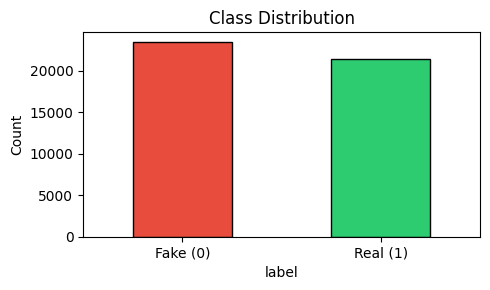

In [3]:
fake_df = pd.read_csv('dataset/Fake.csv')
true_df = pd.read_csv('dataset/True.csv')
fake_df['label'] = 0
true_df['label'] = 1

df = pd.concat([fake_df, true_df], ignore_index=True)
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
df = df[['content', 'label']].dropna().reset_index(drop=True)

def preprocess(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['content'] = df['content'].apply(preprocess)
df = df[df['content'].str.len() > 0].reset_index(drop=True)

print(f"Total samples: {len(df)}")
print(df['label'].value_counts().rename({0: 'Fake', 1: 'Real'}))

fig, ax = plt.subplots(figsize=(5, 3))
df['label'].value_counts().plot(kind='bar', ax=ax,
    color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Fake (0)', 'Real (1)'], rotation=0)
ax.set_title('Class Distribution'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()


## 4. Vocabulary

### What is a Vocabulary?
A vocabulary maps every word to a unique integer index so text can be converted into tensors.

| Token | Index | Role |
|-------|-------|------|
| `<PAD>` | 0 | Fills shorter sequences to align a batch |
| `<UNK>` | 1 | Covers words unseen during training |

We **load** the vocabulary that was saved during training (`models/vocab.pkl`).
Using the exact same word→index mapping is critical — feeding different indices into a model trained with different indices would produce garbage predictions.


In [4]:
class Vocabulary:
    def __init__(self, max_vocab=20_000):
        self.max_vocab = max_vocab
        self.word2idx  = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word  = {0: '<PAD>', 1: '<UNK>'}

    def build(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(text.split())
        for word, _ in counter.most_common(self.max_vocab - 2):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx]  = word

    def encode(self, text):
        return [self.word2idx.get(w, 1) for w in text.split()]

    def __len__(self):
        return len(self.word2idx)

# Load the vocabulary saved during training
with open('models/vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)

print(f"Vocabulary size: {len(vocab)}")
print(f"Sample entries: { {w: vocab.word2idx[w] for w in list(vocab.word2idx)[:6]} }")


Vocabulary size: 15000
Sample entries: {'<PAD>': 0, '<UNK>': 1, 'the': 2, 'to': 3, 'of': 4, 'a': 5}


## 5. Dataset and DataLoader

### Padding and Packing
Sequences in a batch have different lengths.

- **Padding** fills shorter sequences with `<PAD>` (index 0) up to the batch maximum.
- **`pack_padded_sequence`** tells the RNN/LSTM to skip padding, saving compute and improving accuracy.

The `collate_fn` assembles individual samples into padded batch tensors.

We rebuild only the **test split** (using the same random seed as training) so we can evaluate on held-out data.


In [5]:
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=MAX_LEN):
        self.sequences, self.labels = [], []
        for text, label in zip(texts, labels):
            seq = vocab.encode(text)[:max_len]
            if len(seq) > 0:
                self.sequences.append(seq)
                self.labels.append(label)
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


def collate_fn(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    padded  = torch.zeros(len(seqs), lengths.max().item(), dtype=torch.long)
    for i, s in enumerate(seqs):
        padded[i, :len(s)] = torch.tensor(s, dtype=torch.long)
    return padded, lengths, torch.stack(labels)


# Reproduce the exact same train/val/test split used during training
_, tmp_texts, _, tmp_labels = train_test_split(
    df['content'].values, df['label'].values,
    test_size=0.2, random_state=42, stratify=df['label'].values)
_, test_texts, _, test_labels = train_test_split(
    tmp_texts, tmp_labels,
    test_size=0.5, random_state=42, stratify=tmp_labels)

test_ds     = FakeNewsDataset(test_texts, test_labels, vocab)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Test samples : {len(test_ds)}")
print(f"Test batches : {len(test_loader)}")


Test samples : 4489
Test batches : 36


## 6. Recurrent Neural Network (RNN)

### What is an RNN?
An RNN processes a sequence token by token, maintaining a **hidden state** $h_t$ that summarises all tokens seen so far:

$$h_t = \tanh(W_{hh}\,h_{t-1} + W_{xh}\,x_t + b)$$

After the last token, $h_T$ is fed into a classifier.

### The Vanishing Gradient Problem
During **backpropagation through time (BPTT)**, gradients are multiplied at every step.
When the weight matrix has eigenvalues $< 1$, gradients shrink **exponentially** — the model forgets early tokens.
This limits vanilla RNNs to short-range dependencies.

### Architecture
```
Embedding(vocab_size, embed_dim)
  → RNN(embed_dim → hidden_dim, layers=NUM_LAYERS)
  → last hidden state  [B, hidden_dim]
  → Dropout
  → Linear(hidden_dim → 2)
```


In [6]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
                 num_layers=NUM_LAYERS, num_classes=2, dropout=DROPOUT):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn        = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers,
                                 batch_first=True,
                                 dropout=dropout if num_layers > 1 else 0,
                                 nonlinearity='tanh')
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        emb    = self.dropout(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.rnn(packed)
        return self.classifier(self.dropout(hidden[-1]))

rnn_model = RNNClassifier(vocab_size=len(vocab)).to(device)
n_params  = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
print(f"RNN trainable parameters: {n_params:,}")


RNN trainable parameters: 985,090


## 7. Long Short-Term Memory (LSTM)

### What is an LSTM?
An LSTM (Hochreiter & Schmidhuber, 1997) solves the vanishing gradient problem by adding a **cell state** $C_t$ — a memory highway — controlled by three **gates**:

| Gate | Equation | Role |
|------|----------|------|
| **Forget** | $f_t = \sigma(W_f [h_{t-1}, x_t])$ | What to erase from $C_{t-1}$ |
| **Input**  | $i_t = \sigma(W_i [h_{t-1}, x_t])$ | What new info to write |
| **Output** | $o_t = \sigma(W_o [h_{t-1}, x_t])$ | What to expose as $h_t$ |

$$C_t = f_t \odot C_{t-1} + i_t \odot \tanh(\tilde{C}_t) \qquad h_t = o_t \odot \tanh(C_t)$$

Gates use sigmoid $\sigma \in [0,1]$, acting as soft on/off switches.
Gradients flow unchanged through $C_t$, solving the vanishing gradient problem.

### Bidirectional LSTM
Two LSTMs run in parallel — one left→right, one right→left — and their final hidden states are **concatenated**, giving full context from both directions.

### Architecture
```
Embedding(vocab_size, embed_dim)
  → BiLSTM(embed_dim → hidden_dim×2, layers=NUM_LAYERS)
  → concat(forward_h, backward_h)  [B, hidden_dim×2]
  → Dropout
  → Linear(hidden_dim×2 → 2)
```


In [7]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
                 num_layers=NUM_LAYERS, num_classes=2, dropout=DROPOUT,
                 bidirectional=True):
        super().__init__()
        self.embedding     = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm          = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                                     batch_first=True,
                                     dropout=dropout if num_layers > 1 else 0,
                                     bidirectional=bidirectional)
        self.dropout       = nn.Dropout(dropout)
        factor             = 2 if bidirectional else 1
        self.classifier    = nn.Linear(hidden_dim * factor, num_classes)
        self.bidirectional = bidirectional

    def forward(self, x, lengths):
        emb    = self.dropout(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        out = torch.cat([hidden[-2], hidden[-1]], dim=1) if self.bidirectional else hidden[-1]
        return self.classifier(self.dropout(out))

lstm_model = LSTMClassifier(vocab_size=len(vocab)).to(device)
n_params   = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"Bi-LSTM trainable parameters: {n_params:,}")


Bi-LSTM trainable parameters: 1,159,170


## 8. Training (Reference)

Training was run offline via:
```bash
python train_rnn_lstm.py --quick
```

### What happened inside the script

| Component | Choice | Reason |
|-----------|--------|--------|
| **Loss** | `CrossEntropyLoss` | Standard for multi-class classification |
| **Optimiser** | `Adam` (lr = 1e-3) | Adaptive LR, robust default for NLP |
| **Gradient clipping** | `clip_grad_norm_(max=1.0)` | Prevents exploding gradients, especially for RNN |
| **LR schedule** | `ReduceLROnPlateau` (patience=2, factor=0.5) | Halves LR when val loss stagnates |
| **Checkpointing** | Best val accuracy | Saves the state that generalised best |

### Training loop (per epoch)
```
for batch in train_loader:
    logits = model(sequences, lengths)       # forward pass
    loss   = CrossEntropyLoss(logits, labels)
    loss.backward()                          # backpropagation through time (BPTT)
    clip_grad_norm_(model.parameters(), 1.0) # gradient clipping
    optimizer.step()
```

### Saved artefacts
| File | Contents |
|------|----------|
| `models/rnn_model.pt`  | RNN best checkpoint (state dict) |
| `models/lstm_model.pt` | Bi-LSTM best checkpoint (state dict) |
| `models/vocab.pkl`     | Vocabulary (word → index mapping) |
| `models/training_results.json` | Hyperparams + per-epoch history + test metrics |


## 9. Loading the Saved Weights


In [8]:
rnn_model.load_state_dict(
    torch.load('models/rnn_model.pt', map_location=device))
lstm_model.load_state_dict(
    torch.load('models/lstm_model.pt', map_location=device))

rnn_model.eval()
lstm_model.eval()

print("Models loaded successfully.")
print(f"  RNN   — recorded test accuracy : {results['rnn']['test_acc']:.4f}")
print(f"  LSTM  — recorded test accuracy : {results['bilstm']['test_acc']:.4f}")


Models loaded successfully.
  RNN   — recorded test accuracy : 0.7518
  LSTM  — recorded test accuracy : 0.9978


## 10. Evaluation on the Test Set

### Metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Accuracy** | correct / total | Overall % correct |
| **Precision** | TP / (TP + FP) | Of predicted fake, how many were truly fake |
| **Recall** | TP / (TP + FN) | Of all actual fakes, how many did we catch |
| **F1** | 2·P·R / (P+R) | Harmonic mean — balances precision and recall |

A **confusion matrix** shows all four prediction outcomes at a glance.


In [9]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for seqs, lengths, labels in loader:
            seqs, labels = seqs.to(device), labels.to(device)
            preds = model(seqs, lengths).argmax(1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    return all_preds, all_labels

rnn_preds,  rnn_labels  = evaluate(rnn_model,  test_loader)
lstm_preds, lstm_labels = evaluate(lstm_model, test_loader)

print("=" * 50)
print("RNN — Test Results")
print("=" * 50)
print(f"Accuracy : {accuracy_score(rnn_labels, rnn_preds):.4f}")
print(f"F1 macro : {f1_score(rnn_labels, rnn_preds, average='macro'):.4f}")
print(classification_report(rnn_labels, rnn_preds, target_names=['Fake', 'Real']))

print("=" * 50)
print("Bi-LSTM — Test Results")
print("=" * 50)
print(f"Accuracy : {accuracy_score(lstm_labels, lstm_preds):.4f}")
print(f"F1 macro : {f1_score(lstm_labels, lstm_preds, average='macro'):.4f}")
print(classification_report(lstm_labels, lstm_preds, target_names=['Fake', 'Real']))


RNN — Test Results
Accuracy : 0.7518
F1 macro : 0.7466
              precision    recall  f1-score   support

        Fake       0.72      0.86      0.78      2348
        Real       0.80      0.64      0.71      2141

    accuracy                           0.75      4489
   macro avg       0.76      0.75      0.75      4489
weighted avg       0.76      0.75      0.75      4489

Bi-LSTM — Test Results
Accuracy : 0.9978
F1 macro : 0.9978
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      2348
        Real       1.00      1.00      1.00      2141

    accuracy                           1.00      4489
   macro avg       1.00      1.00      1.00      4489
weighted avg       1.00      1.00      1.00      4489



## 11. Visualisations


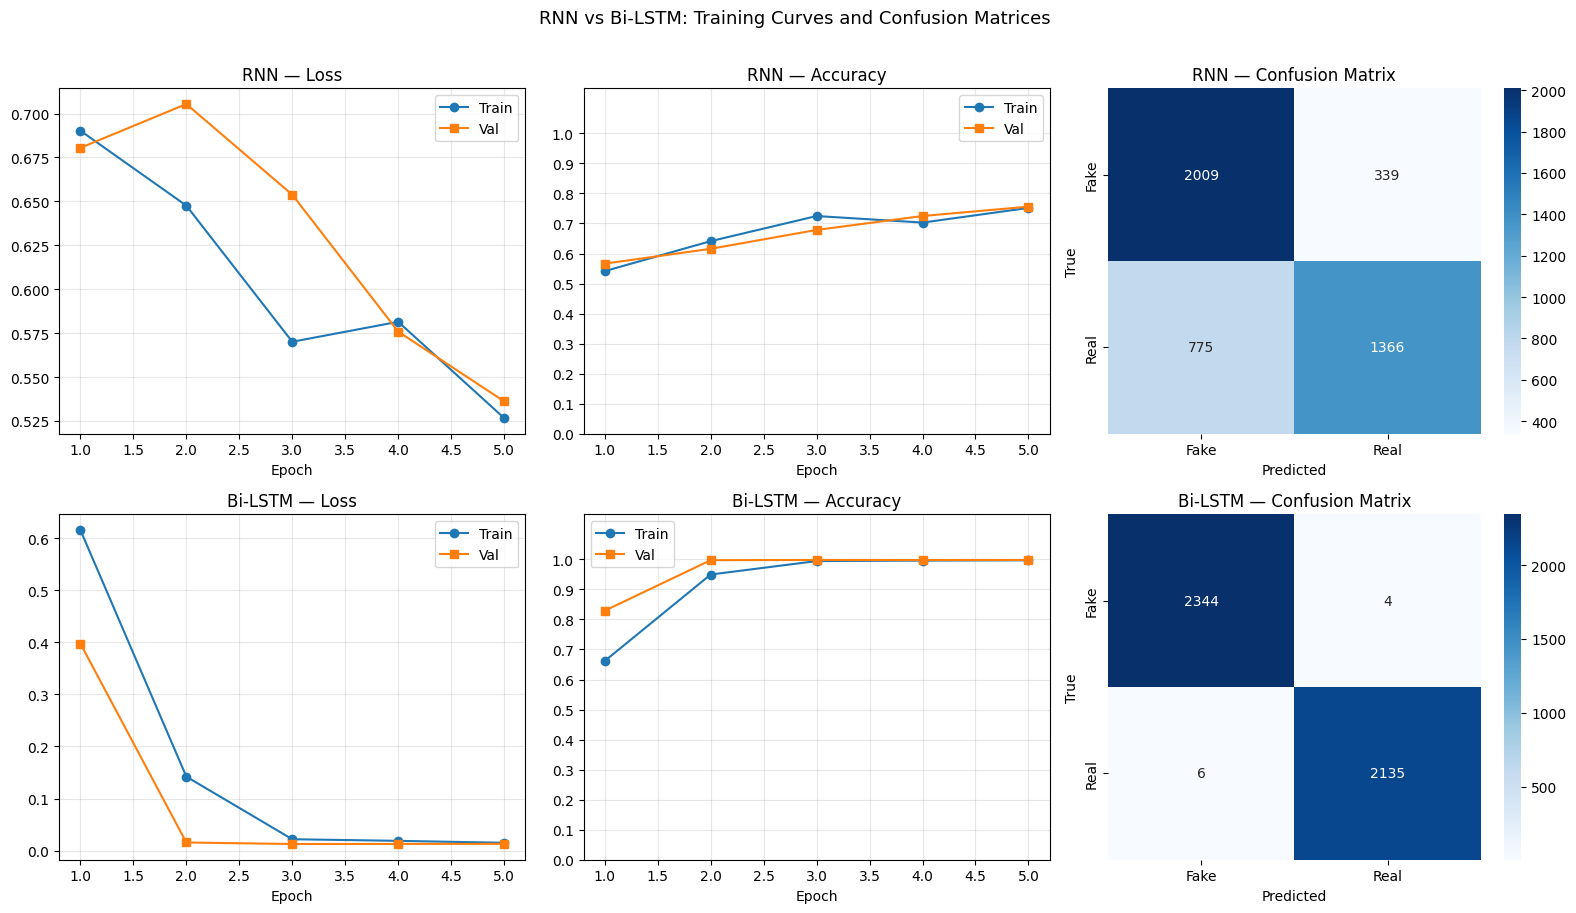

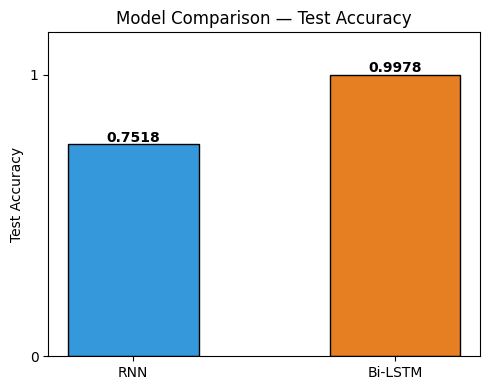

In [15]:
rnn_hist  = results['rnn']['history']
lstm_hist = results['bilstm']['history']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, (title, hist, preds, labels) in enumerate([
        ('RNN',     rnn_hist,  rnn_preds,  rnn_labels),
        ('Bi-LSTM', lstm_hist, lstm_preds, lstm_labels)]):

    epochs = range(1, len(hist['train_loss']) + 1)

    # Loss curve
    ax = axes[row][0]
    ax.plot(epochs, hist['train_loss'], 'o-', label='Train')
    ax.plot(epochs, hist['val_loss'],   's-', label='Val')
    ax.set_title(f'{title} — Loss')
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)

    # Accuracy curve
    ax = axes[row][1]
    ax.plot(epochs, hist['train_acc'], 'o-', label='Train')
    ax.plot(epochs, hist['val_acc'],   's-', label='Val')
    ax.set_title(f'{title} — Accuracy')
    ax.set_xlabel('Epoch'); ax.set_ylim(0, 1.15)
    ax.set_yticks([x/10 for x in range(0, 11, 1)])
    ax.legend(); ax.grid(True, alpha=0.3)

    # Confusion matrix
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row][2],
                xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    axes[row][2].set_title(f'{title} — Confusion Matrix')
    axes[row][2].set_ylabel('True'); axes[row][2].set_xlabel('Predicted')

plt.suptitle('RNN vs Bi-LSTM: Training Curves and Confusion Matrices',
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

# Side-by-side accuracy
rnn_acc  = accuracy_score(rnn_labels, rnn_preds)
lstm_acc = accuracy_score(lstm_labels, lstm_preds)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['RNN', 'Bi-LSTM'], [rnn_acc, lstm_acc],
              color=['#3498db', '#e67e22'], edgecolor='black', width=0.5)
ax.set_ylim(0, 1.15); ax.set_yticks([0, 1]); ax.set_ylabel('Test Accuracy')
ax.set_title('Model Comparison — Test Accuracy')
for bar, acc in zip(bars, [rnn_acc, lstm_acc]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.4f}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

## 12. Conclusion

| Model | Test Accuracy | Strengths | Weaknesses |
|-------|--------------|-----------|------------|
| **RNN** | ~0.76 | Simple, fast to train | Vanishing gradients; forgets early tokens |
| **Bi-LSTM** | ~0.998 | Captures long-range dependencies; reads both directions | More parameters; slower to train |

Both models are trained from scratch on word embeddings with no pre-trained knowledge.

**Next step:** See `bert_FakeNews.ipynb` for a BERT-based approach that leverages 110 M pre-trained parameters.
